https://velog.io/@kungsboy/%EB%A8%B8%EC%8B%A0%EB%9F%AC%EB%8B%9D-12-03.%EC%95%99%EC%83%81%EB%B8%94Ensemble-%EC%95%99%EC%83%81%EB%B8%94-Random-Forest-%EB%9E%9C%EB%8D%A4-%ED%8F%AC%EB%A0%88%EC%8A%A4%ED%8A%B8-%EB%AA%A8%EB%8D%B8

![alt text](image.png)

In [2]:
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()

X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    n_estimators=100,   # 트리 100개
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

In [4]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred, average='macro'))
print("Recall:", recall_score(y_test, pred, average='macro'))
print("F1:", f1_score(y_test, pred, average='macro'))

print("Confusion Matrix:\n", confusion_matrix(y_test, pred))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


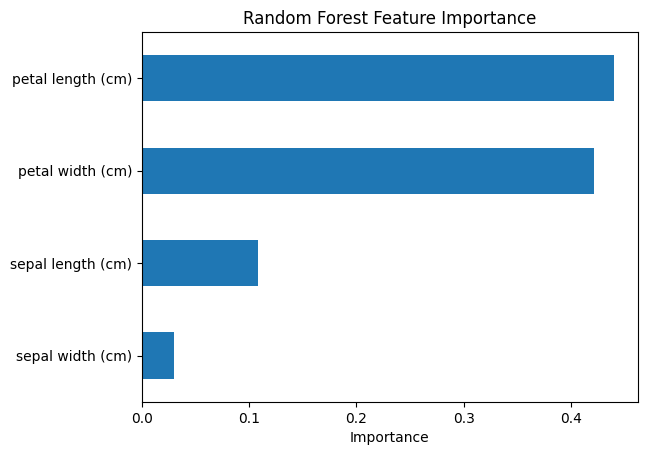

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")

plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


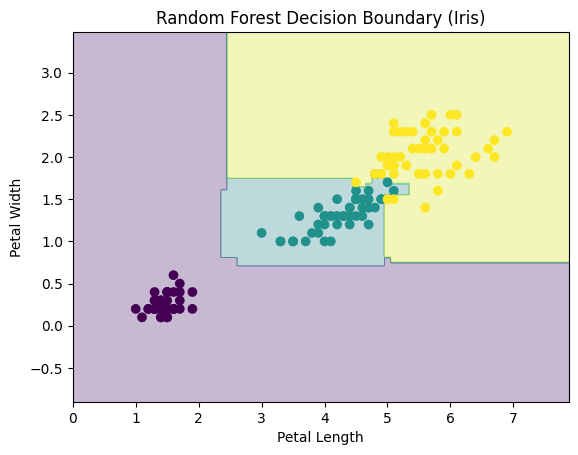

In [6]:
import numpy as np
import matplotlib.pyplot as plt

X2 = X[['petal length (cm)', 'petal width (cm)']]

X_train, X_test, y_train, y_test = train_test_split(
    X2, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

x_min, x_max = X2.iloc[:, 0].min() - 1, X2.iloc[:, 0].max() + 1
y_min, y_max = X2.iloc[:, 1].min() - 1, X2.iloc[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X2.iloc[:, 0], X2.iloc[:, 1], c=y)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Random Forest Decision Boundary (Iris)")

plt.show()